In [1]:
# Importing libraries for data manipulation
import pandas as pd
import numpy as np

# Libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Better visualization
sns.set_style("whitegrid")

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("walmart_merged.csv")
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [4]:
df.tail()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
421565,45,98,2012-09-28,508.37,False,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,B,118221
421566,45,98,2012-10-05,628.10,False,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667,B,118221
421567,45,98,2012-10-12,1061.02,False,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667,B,118221
421568,45,98,2012-10-19,760.01,False,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667,B,118221
421569,45,98,2012-10-26,1076.80,False,58.85,3.882,4018.91,58.08,100.00,211.94,858.33,192.308899,8.667,B,118221


In [6]:
df.shape

(421570, 16)

In [5]:
df.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Temperature   421570 non-null  float64
 6   Fuel_Price    421570 non-null  float64
 7   MarkDown1     150681 non-null  float64
 8   MarkDown2     111248 non-null  float64
 9   MarkDown3     137091 non-null  float64
 10  MarkDown4     134967 non-null  float64
 11  MarkDown5     151432 non-null  float64
 12  CPI           421570 non-null  float64
 13  Unemployment  421570 non-null  float64
 14  Type          421570 non-null  object 
 15  Size          421570 non-null  int64  
dtypes: bool(1), float64(10), int64(3), object(2)
memory usage: 48.6+ MB


### Observation

- The dataset consists of **421,570 observations** and **16 features**.
- It contains **3 integer**, **10 floating-point**, **2 object**, and **1 boolean** features.
- Most features are complete with no missing values.
- The **MarkDown1-MarkDown5** columns contain a significant number of missing values.
- The **Date** column is stored as an object and will be converted to datetime format during preprocessing.
- The dataset size is approximately **46 MB**, which is suitable for exploratory data analysis and machine learning.

## Data Types

The `dtypes` attribute returns the data type of each feature in the dataset.

Understanding the data type of each feature is important because different preprocessing and visualization techniques are applied to numerical, categorical, boolean, and datetime features.

In [8]:
df.dtypes

Store             int64
Dept              int64
Date             object
Weekly_Sales    float64
IsHoliday          bool
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float64
Unemployment    float64
Type             object
Size              int64
dtype: object

"Different data types require different preprocessing techniques. Numerical features can be analyzed using descriptive statistics and scaling if needed, while categorical features require encoding. I also identified that the Date column needed conversion to datetime so that meaningful time-based features could be extracted."

## Missing Value Analysis

Missing value analysis is one of the most important steps in Exploratory Data Analysis (EDA).

Missing values can reduce model performance and may introduce bias if not handled correctly.

In this step, we will:
- Identify columns containing missing values.
- Count the number of missing values in each column.
- Calculate the percentage of missing values.
- Decide later on the most appropriate imputation strategy based on the data.

In [9]:
missing_values = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_values = missing_values[missing_values['Missing Values'] > 0]

missing_values.sort_values(by='Percentage', ascending=False)

,Missing Values,Percentage
MarkDown2,310322,73.611025
MarkDown4,286603,67.984676
MarkDown3,284479,67.480845
MarkDown1,270889,64.257181
MarkDown5,270138,64.079038


### Observation

- Missing values are present only in the **MarkDown1–MarkDown5** features.
- The percentage of missing values ranges from **64.08%** to **73.61%**, indicating a substantial amount of missing data.
- No missing values are observed in the target variable (`Weekly_Sales`) or other important predictor variables such as `Temperature`, `Fuel_Price`, `CPI`, and `Unemployment`.
- Since the missing values are confined to promotional features, they may represent weeks with no promotional activity rather than missing information.
- Therefore, no imputation or feature removal will be performed at this stage. The appropriate treatment will be decided after further exploratory analysis.

"Your dataset had over 70% missing values in some columns. Why didn't you drop them?"


"I first considered the business context. The missing values were limited to promotional MarkDown features. Since missing entries could indicate that no promotion was running rather than a data collection error, dropping or imputing them immediately could distort the data. I postponed the decision until after exploratory analysis and feature understanding."

## Duplicate Value Analysis

Duplicate records can negatively impact data analysis and machine learning models by introducing bias and giving undue importance to repeated observations.

In this step, we will check whether the dataset contains any duplicate rows. If duplicates exist, we will decide whether they should be removed based on the nature of the data.

In [10]:
duplicate_rows = df.duplicated().sum()

print(f"Total Duplicate Rows: {duplicate_rows}")

Total Duplicate Rows: 0


### Observation

- The dataset contains **no duplicate rows**.
- Every record in the dataset is unique.
- Since no duplicate observations are present, no duplicate removal is required.
- The dataset is clean with respect to duplicate records and is ready for further exploratory data analysis.

Did you remove duplicates from your dataset?"


"I first checked for duplicate records using df.duplicated().sum(). The result showed that there were no duplicate rows, so no removal was necessary. I always verify duplicates before preprocessing because removing valid observations can lead to information loss."

## Identifying Numerical and Categorical Features

Before performing exploratory data analysis, it is important to separate numerical and categorical features.

- **Numerical features** contain quantitative values and are analyzed using statistical measures and visualizations such as histograms, boxplots, and correlation heatmaps.
- **Categorical features** contain labels or categories and are analyzed using frequency distributions and count plots.

In [11]:
# Numerical Features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns

# Categorical Features
categorical_features = df.select_dtypes(include=['object', 'bool']).columns

print("Number of Numerical Features:", len(numerical_features))
print(numerical_features)

print("\nNumber of Categorical Features:", len(categorical_features))
print(categorical_features)

Number of Numerical Features: 13
Index(['Store', 'Dept', 'Weekly_Sales', 'Temperature', 'Fuel_Price',
       'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI',
       'Unemployment', 'Size'],
      dtype='object')

Number of Categorical Features: 3
Index(['Date', 'IsHoliday', 'Type'], dtype='object')


### Observation

- The dataset contains **13 numerical** and **3 categorical** features based on their data types.
- Among the numerical features, **Store** and **Dept** are identifier variables rather than continuous numerical variables.
- The remaining numerical features represent measurable quantities and will be analyzed using descriptive statistics and visualization techniques.
- The categorical features include **Date**, **IsHoliday**, and **Type**.
- The **Date** feature will be converted to the datetime format during preprocessing so that useful time-based features can be extracted.

## Statistical Summary of Numerical Features

Descriptive statistics provide a quick overview of the numerical features in the dataset.

The `describe()` function summarizes important statistical measures such as:

- Count
- Mean
- Standard Deviation
- Minimum Value
- 25th Percentile (Q1)
- Median (50th Percentile)
- 75th Percentile (Q3)
- Maximum Value

These statistics help identify the distribution, spread, variability, and potential outliers in the dataset.

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,421570.0,22.200546,12.785297,1.000,11.000000,22.00000,33.000000,45.000000
Dept,421570.0,44.260317,30.492054,1.000,18.000000,37.00000,74.000000,99.000000
Weekly_Sales,421570.0,15981.258123,22711.183519,-4988.940,2079.650000,7612.03000,20205.852500,693099.360000
Temperature,421570.0,60.090059,18.447931,-2.060,46.680000,62.09000,74.280000,100.140000
Fuel_Price,421570.0,3.361027,0.458515,2.472,2.933000,3.45200,3.738000,4.468000
MarkDown1,150681.0,7246.420196,8291.221345,0.270,2240.270000,5347.45000,9210.900000,88646.760000
MarkDown2,111248.0,3334.628621,9475.357325,-265.760,41.600000,192.00000,1926.940000,104519.540000
MarkDown3,137091.0,1439.421384,9623.078290,-29.100,5.080000,24.60000,103.990000,141630.610000
MarkDown4,134967.0,3383.168256,6292.384031,0.220,504.220000,1481.31000,3595.040000,67474.850000
MarkDown5,151432.0,4628.975079,5962.887455,135.160,1878.440000,3359.45000,5563.800000,108519.280000


### Observation

- The **Weekly_Sales** feature exhibits high variability, with a mean of **15,981.26** and a standard deviation of **22,711.18**.
- The median (**7,612.03**) is considerably lower than the mean, suggesting that the distribution of weekly sales is positively skewed.
- Negative values are present in the **Weekly_Sales** feature, which may correspond to product returns or sales adjustments.
- The **Temperature**, **Fuel_Price**, **CPI**, and **Unemployment** features fall within realistic ranges and do not indicate obvious inconsistencies.
- The **Store Size** feature shows substantial variation, indicating differences in store capacities.
- The **MarkDown** features contain fewer observations because of the large number of missing values identified earlier.

How can you identify skewness using describe()

"I compare the mean and the median. If the mean is significantly greater than the median, the distribution is usually positively skewed. If the mean is less than the median, it indicates negative skewness. I then confirm this using histograms and boxplots."

## Distribution Analysis of the Target Variable

The target variable, **Weekly_Sales**, represents the weekly sales generated by each department in a store.

Understanding its distribution is important because:

- It helps identify skewness in the data.
- It reveals whether the data follows a normal distribution.
- It highlights the presence of extreme values (outliers).
- It helps determine whether transformations (such as logarithmic transformation) may improve model performance.

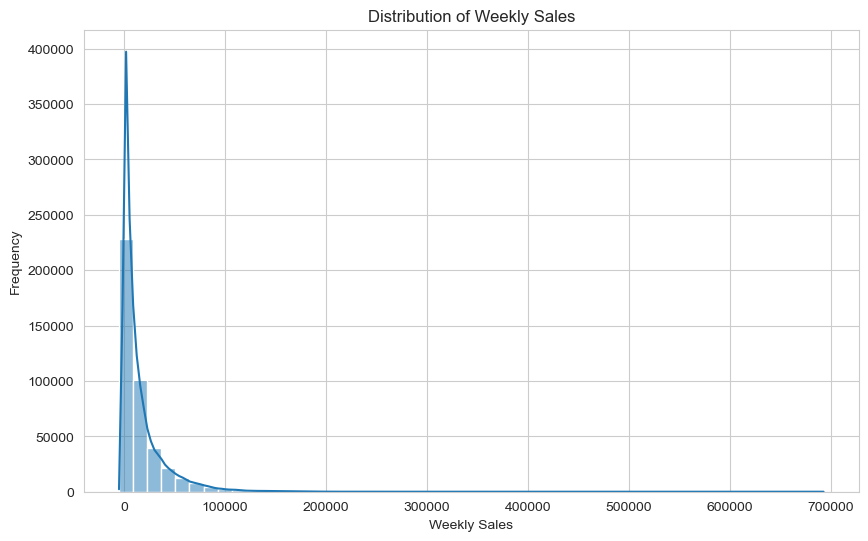

In [13]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='Weekly_Sales',
    bins=50,
    kde=True
)

plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")

plt.show()

Your target variable is highly right-skewed. What would you do?"


"First, I'd verify whether the extreme values are genuine business observations or data errors. Since retail sales often have seasonal spikes, I wouldn't remove them without justification. If I were using a linear model, I might consider an appropriate transformation after checking the data. For tree-based models like XGBoost or Random Forest, I would typically keep the original target because these models are much less sensitive to skewness."

## Boxplot Analysis of the Target Variable

A boxplot summarizes the distribution of a numerical feature using its quartiles.

It helps identify:

- Median
- Interquartile Range (IQR)
- Spread of the data
- Potential outliers

This complements the histogram by providing a compact summary of the distribution.

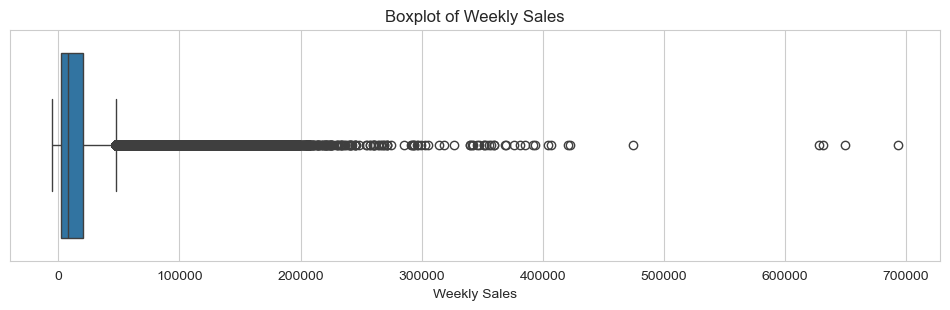

In [14]:
plt.figure(figsize=(12, 3))

sns.boxplot(
    x=df['Weekly_Sales']
)

plt.title("Boxplot of Weekly Sales")
plt.xlabel("Weekly Sales")

plt.show()

### Observation

- The boxplot confirms that the **Weekly_Sales** feature contains a large number of high-value observations beyond the upper whisker.
- These observations are statistical outliers identified using the Interquartile Range (IQR) method.
- The distribution is highly right-skewed, with the majority of sales concentrated within a relatively narrow range and a long upper tail.
- Since the dataset represents retail sales, these high-value observations are likely to correspond to genuine business events such as holiday seasons or promotional campaigns.
- Therefore, the outliers will be retained for further analysis rather than removed at this stage.

"Your boxplot shows thousands of outliers. Why didn't you remove them?"

A strong answer would be:

"A boxplot identifies statistical outliers using the IQR rule, but statistical outliers are not necessarily data errors. In a retail sales dataset, unusually high sales can occur during holidays, promotions, or peak shopping seasons. Removing them without business justification could reduce the model's ability to learn important patterns. Therefore, I retained these observations and planned to validate them further during business and time series analysis."

## Distribution Analysis of Temperature

Temperature is an environmental feature that may influence customer shopping behavior.

Analyzing its distribution helps us:

- Understand the range of temperatures recorded.
- Detect skewness in the data.
- Identify unusual temperature observations.
- Assess whether the feature follows an approximately normal distribution.

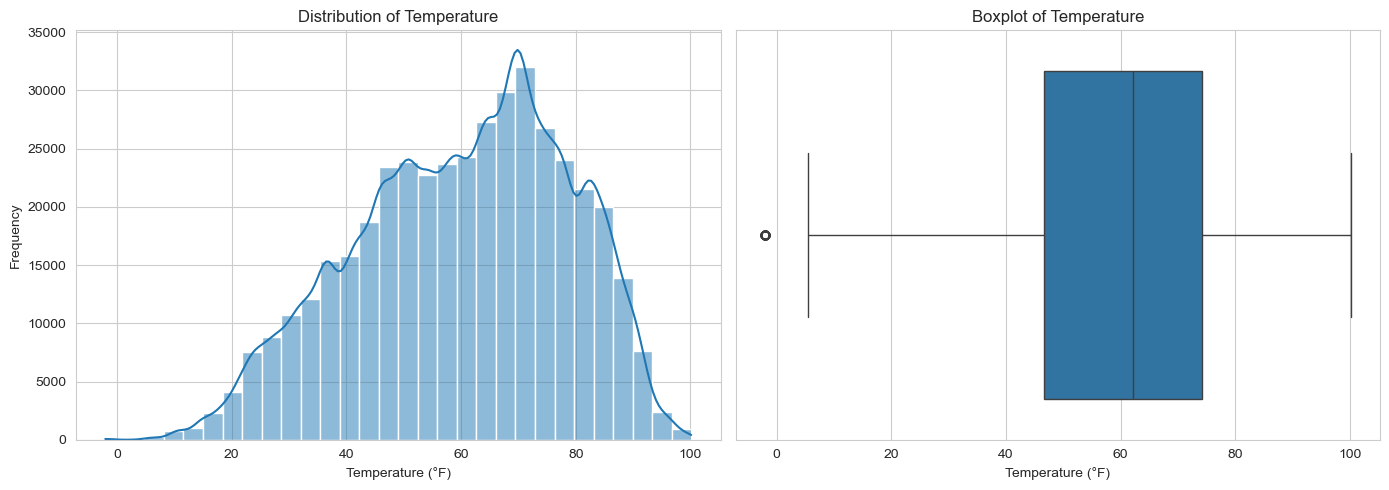

In [15]:
plt.figure(figsize=(14,5))

# Histogram
plt.subplot(1,2,1)

sns.histplot(
    data=df,
    x='Temperature',
    bins=30,
    kde=True
)

plt.title("Distribution of Temperature")
plt.xlabel("Temperature (°F)")
plt.ylabel("Frequency")


# Boxplot
plt.subplot(1,2,2)

sns.boxplot(
    x=df['Temperature']
)

plt.title("Boxplot of Temperature")
plt.xlabel("Temperature (°F)")

plt.tight_layout()
plt.show()

### Observation

- The Temperature feature exhibits an approximately bell-shaped distribution with slight negative skewness.
- The KDE curve suggests the presence of multiple peaks, which may be attributed to stores located in different geographical regions with varying climatic conditions.
- Only one low-temperature observation appears outside the whiskers in the boxplot, and it is considered a realistic weather observation rather than a data error.
- Overall, the Temperature feature appears to be well distributed and does not require outlier treatment at this stage.

"Your histogram isn't perfectly normal. Is that a problem?"


"Not necessarily. Many real-world features do not follow a perfect normal distribution. Tree-based machine learning algorithms such as Random Forest, XGBoost, LightGBM, and CatBoost do not require normally distributed input features. The more important consideration is whether the observed values are realistic and whether the distribution reflects genuine business conditions."

## Distribution Analysis of Fuel Price

Fuel price is an economic indicator that may indirectly influence customer purchasing behavior and transportation costs.

Analyzing its distribution helps us:

- Understand the variation in fuel prices during the observation period.
- Detect skewness and unusual observations.
- Assess whether the feature contains potential outliers.

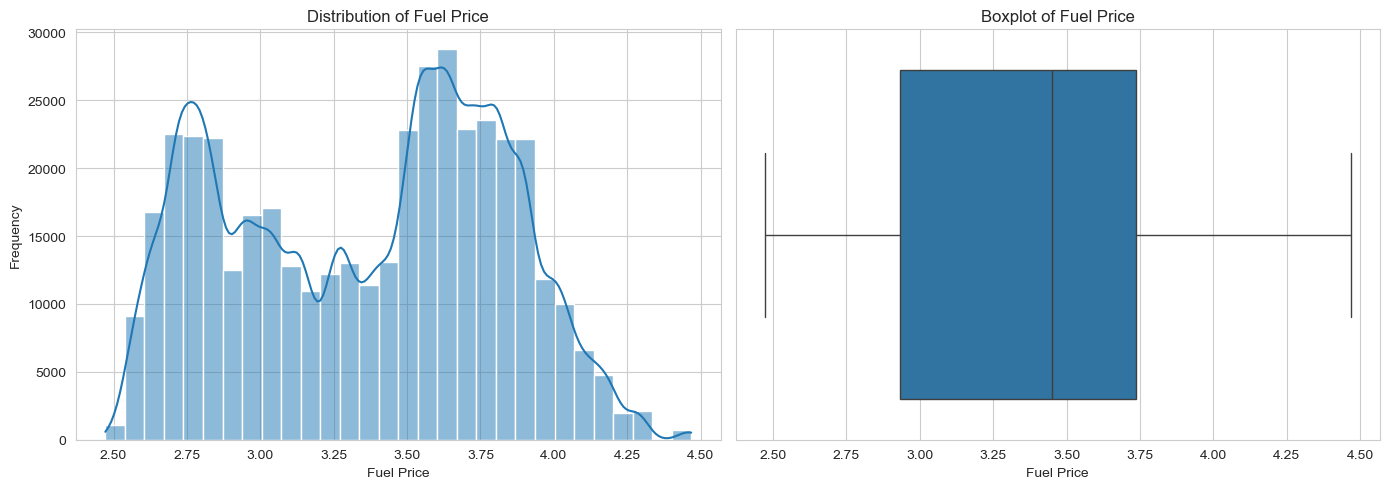

In [16]:
plt.figure(figsize=(14,5))

# Histogram
plt.subplot(1,2,1)

sns.histplot(
    data=df,
    x='Fuel_Price',
    bins=30,
    kde=True
)

plt.title("Distribution of Fuel Price")
plt.xlabel("Fuel Price")
plt.ylabel("Frequency")

# Boxplot
plt.subplot(1,2,2)

sns.boxplot(
    x=df['Fuel_Price']
)

plt.title("Boxplot of Fuel Price")
plt.xlabel("Fuel Price")

plt.tight_layout()
plt.show()

### Observation

- The **Fuel_Price** feature exhibits a **multimodal distribution**, indicating that fuel prices varied across different time periods during data collection.
- The boxplot does not reveal any significant outliers, suggesting that the observed fuel prices fall within a reasonable range.
- The distribution spans approximately **2.47 to 4.47**, reflecting realistic fluctuations in fuel prices over the study period.
- Since fuel price is an external economic indicator, it may indirectly influence consumer purchasing behavior and retail sales.
- Overall, the feature appears to be clean and does not require any outlier treatment or transformation at this stage.

Why do you think Fuel Price has multiple peaks instead of a normal distribution?"


"Fuel prices change over time due to market conditions rather than being randomly distributed. Since the dataset spans multiple years and different economic conditions, the histogram shows multiple peaks corresponding to different fuel price levels during different periods. This represents genuine temporal variation rather than a data quality issue."

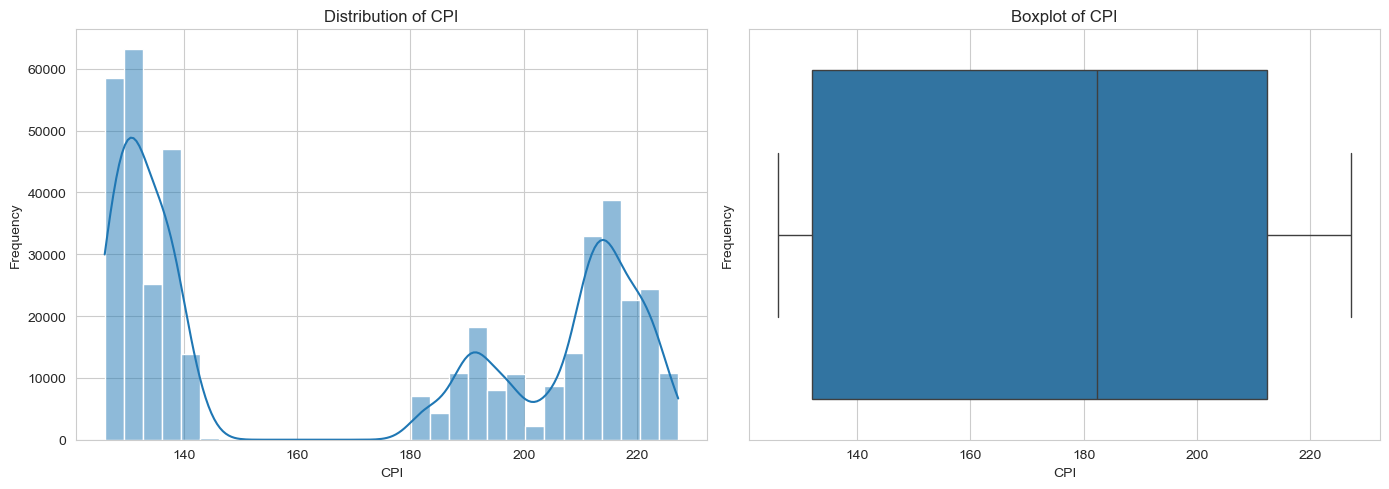

In [ ]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.histplot(
    data=df,
    x='CPI',
    bins=30,
    kde=True
)

plt.title("Distribution of CPI")
plt.xlabel("CPI")
plt.ylabel("Frequency")

plt.subplot(1,2,2)

sns.boxplot(
    x=df['CPI']
)

plt.title("Boxplot of CPI")
plt.xlabel("CPI")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

###
1.The distribution appears to have three distinct peaks approximately around:

  i. 128–138
  ii.188–195
  iii. 210–220 
2.There is no outliers present in this column.


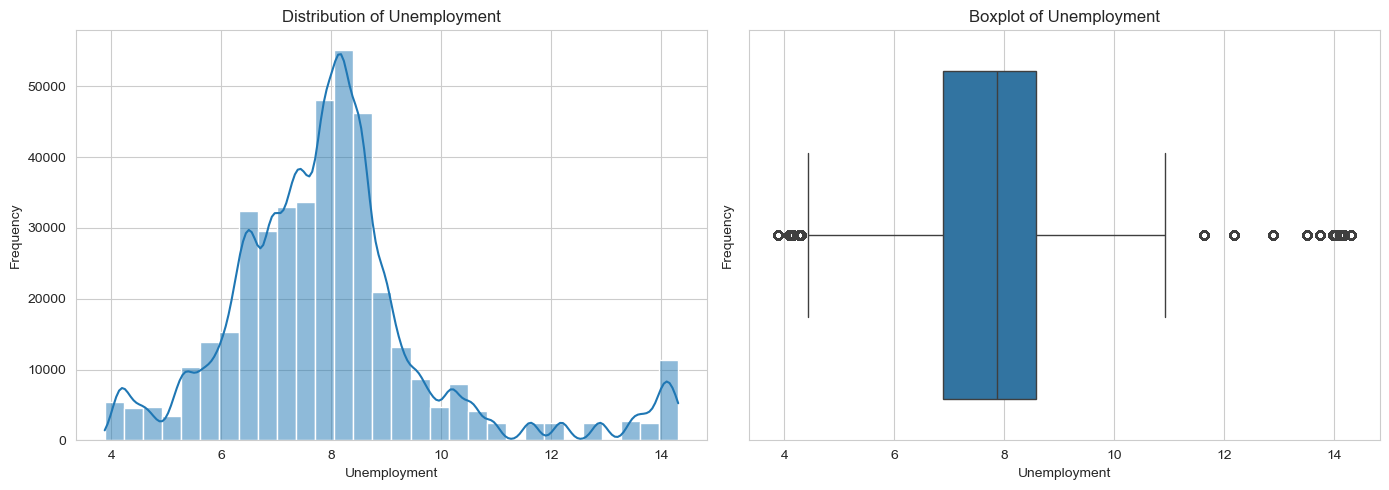

In [21]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.histplot(
    data=df,
    x='Unemployment',
    bins=30,
    kde=True
)

plt.title("Distribution of Unemployment")
plt.xlabel("Unemployment")
plt.ylabel("Frequency")

plt.subplot(1,2,2)

sns.boxplot(
    x=df['Unemployment']
)

plt.title("Boxplot of Unemployment")
plt.xlabel("Unemployment")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Observation

- The **Unemployment** feature exhibits an approximately bell-shaped distribution with **moderate positive skewness**.
- Most unemployment values are concentrated between **6% and 9%**, indicating that the majority of observations fall within a typical economic range.
- The boxplot identifies a small number of statistical outliers on both the lower and higher ends of the distribution.
- These extreme unemployment values are likely to reflect genuine economic conditions across different regions and time periods rather than data quality issues.
- Therefore, no outlier treatment is required for this feature at this stage.

Why didn't you remove unemployment outliers?

A good answer:

"Unemployment is an economic indicator that naturally varies across locations and time periods. The extreme values are statistically identified as outliers by the IQR method, but they are economically plausible and therefore should be retained unless there is evidence of data errors."

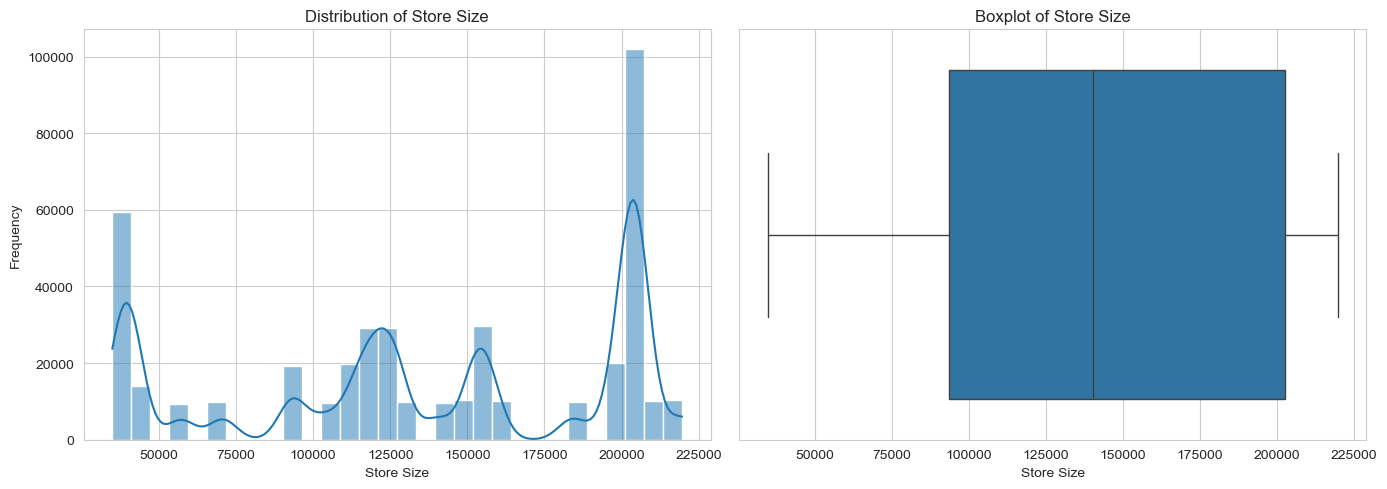

In [24]:
plt.figure(figsize=(14,5))

# Histogram
plt.subplot(1,2,1)

sns.histplot(
    data=df,
    x='Size',
    bins=30,
    kde=True
)

plt.title("Distribution of Store Size")
plt.xlabel("Store Size")
plt.ylabel("Frequency")

# Boxplot
plt.subplot(1,2,2)

sns.boxplot(
    x=df['Size']
)

plt.title("Boxplot of Store Size")
plt.xlabel("Store Size")

plt.tight_layout()
plt.show()

### Observation

- The **Store Size** feature exhibits a **multimodal distribution**, indicating the presence of multiple categories of store sizes.
- The histogram shows distinct clusters rather than a single continuous distribution, suggesting that Walmart operates stores with standardized layouts or formats.
- The boxplot does not indicate any significant statistical outliers, implying that all store sizes fall within the expected range.
- The wide variation in store sizes suggests that this feature may significantly influence weekly sales and should be explored further during business analysis and correlation analysis.
- No preprocessing or outlier treatment is required for this feature at this stage.

Why do you think Store Size has multiple peaks?


"The multimodal distribution suggests that Walmart operates stores in different standardized formats rather than constructing stores with continuously varying sizes. These clusters likely represent small stores, medium-sized stores, large stores, and supercenters. This pattern reflects business decisions rather than data quality issues."

## Summary of Univariate Analysis

The numerical features were analyzed using histograms and boxplots to understand their distributions, identify skewness, and detect potential outliers.

### Key Findings

- **Weekly_Sales** is highly positively skewed and contains several high-value observations corresponding to genuine business events.
- **Temperature** follows an approximately bell-shaped distribution with slight negative skewness and no significant outliers.
- **Fuel_Price** and **CPI** exhibit multimodal distributions, reflecting changes across different time periods.
- **Unemployment** is approximately bell-shaped with moderate positive skewness and a few statistically identified but economically valid outliers.
- **Store Size** exhibits a multimodal distribution, indicating the presence of multiple standardized store formats.
- None of the numerical features require outlier removal at this stage, as the observed extreme values are consistent with realistic business or economic conditions.

# Univariate Analysis of Promotional (MarkDown) Features

The **MarkDown1–MarkDown5** features represent different promotional markdown events introduced by Walmart.

These variables contain a substantial number of missing values.

Before performing any imputation, it is important to understand:

- Their distributions.
- The extent of missing values.
- Whether the missing values appear to represent the absence of promotions.
- The presence of outliers.
- Whether the variables require transformation or special preprocessing.

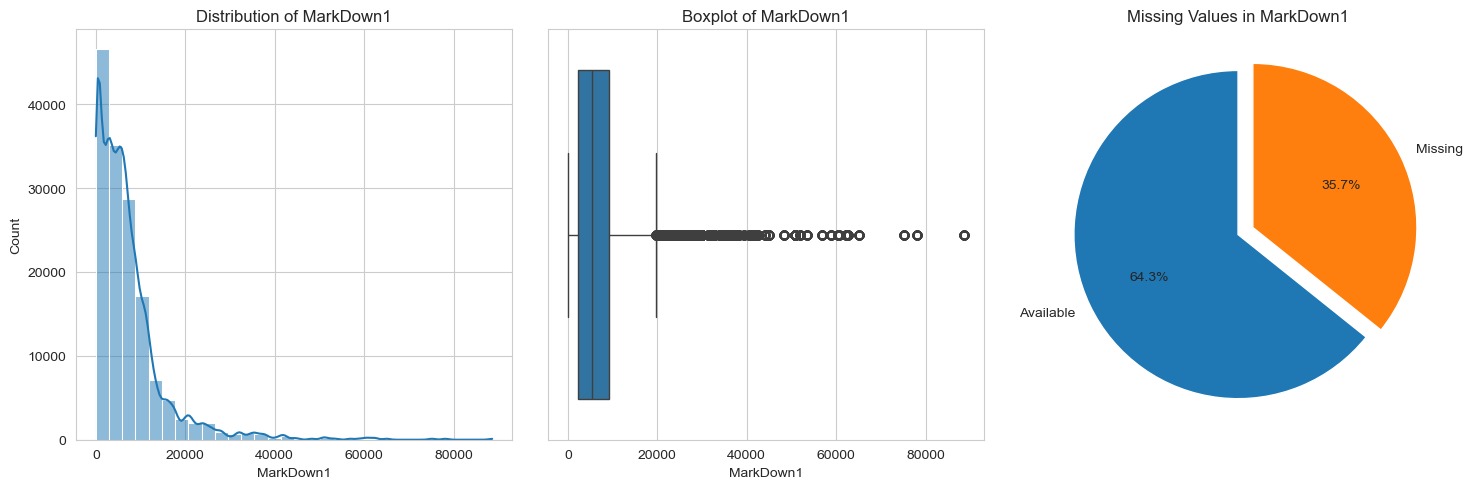

In [25]:
plt.figure(figsize=(15,5))

# Histogram
plt.subplot(1,3,1)

sns.histplot(
    data=df,
    x='MarkDown1',
    bins=30,
    kde=True
)

plt.title("Distribution of MarkDown1")


# Boxplot
plt.subplot(1,3,2)

sns.boxplot(
    x=df['MarkDown1']
)

plt.title("Boxplot of MarkDown1")


# Missing Values
plt.subplot(1,3,3)

missing = df['MarkDown1'].isnull().value_counts()

plt.pie(
    missing,
    labels=['Available','Missing'],
    autopct='%1.1f%%',
    startangle=90,
    explode=[0,0.1]
)

plt.title("Missing Values in MarkDown1")

plt.tight_layout()
plt.show()

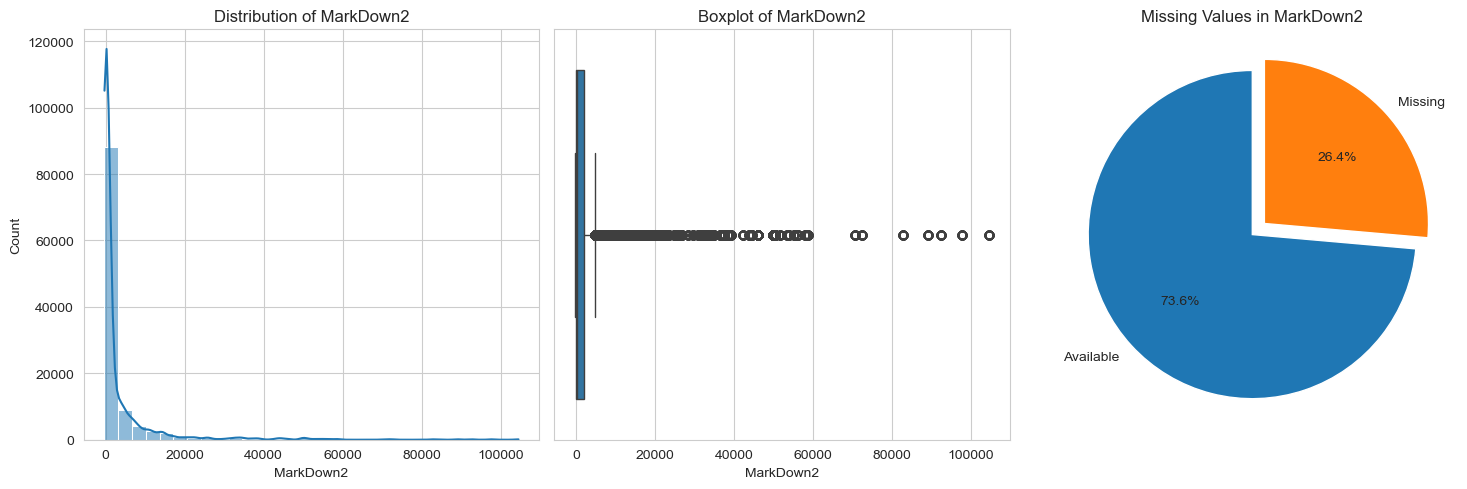

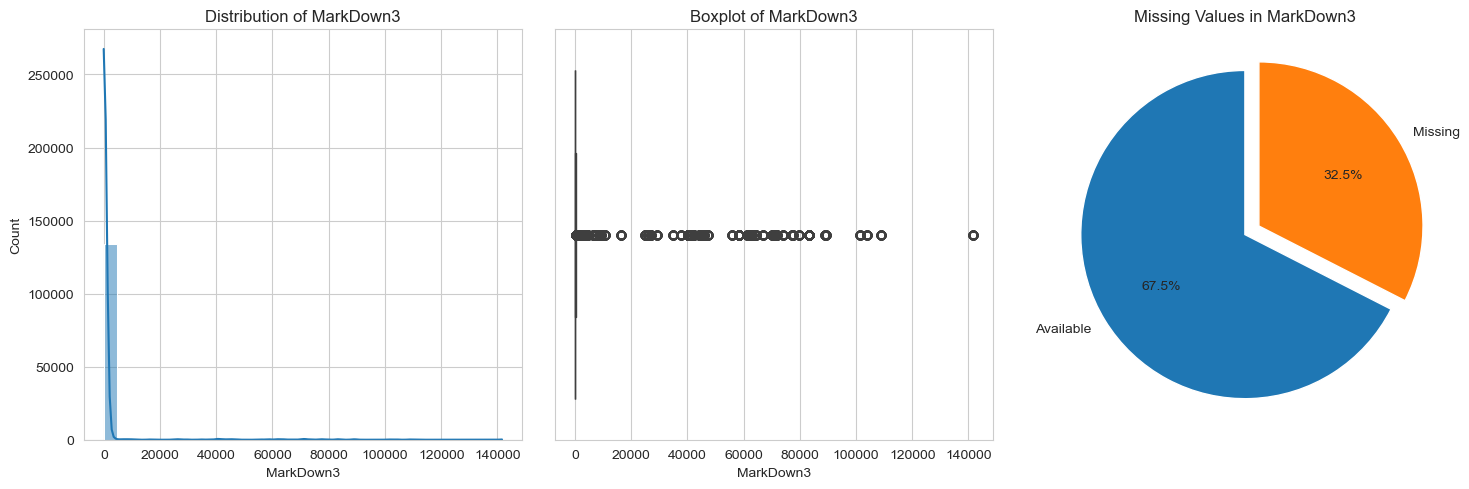

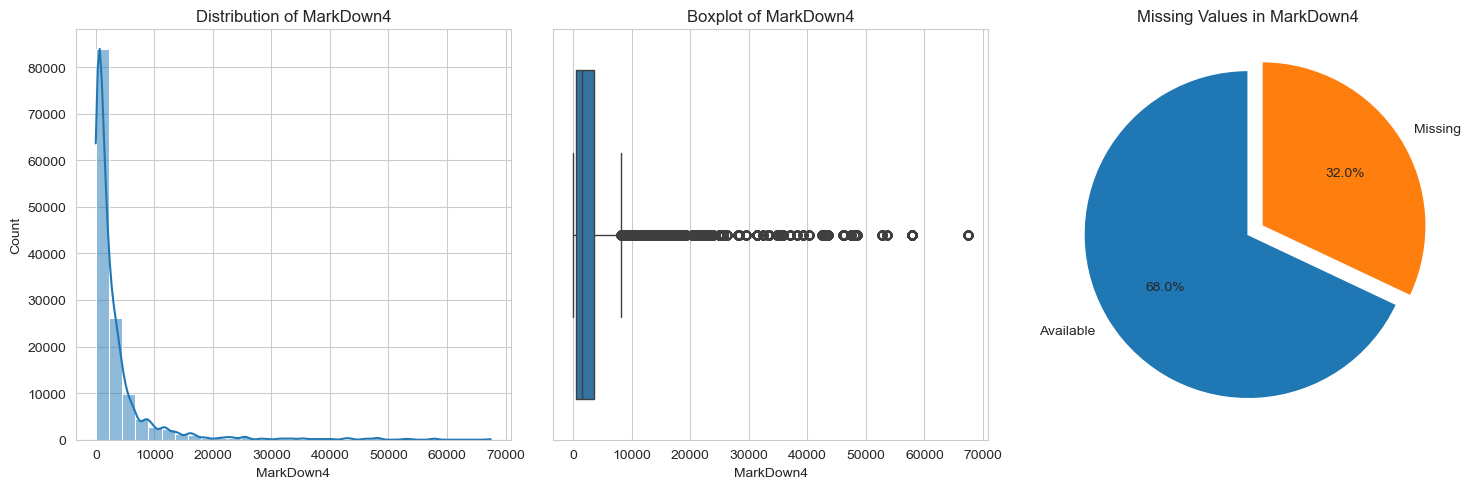

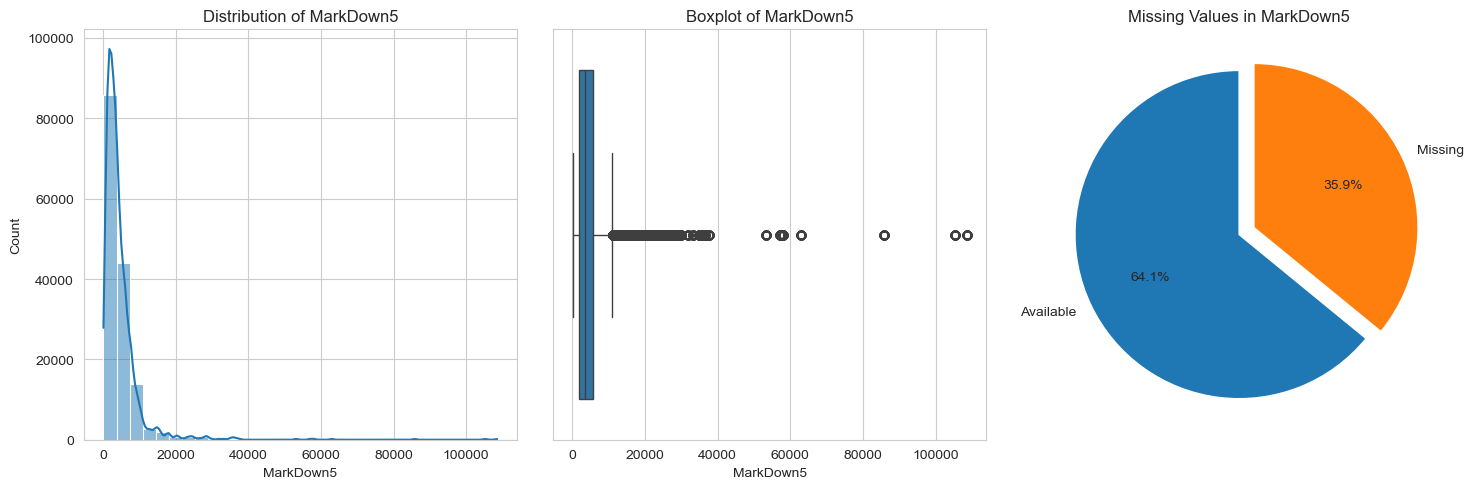

In [26]:
markdown_features = [
    'MarkDown2',
    'MarkDown3',
    'MarkDown4',
    'MarkDown5'
]

for feature in markdown_features:

    plt.figure(figsize=(15,5))

    # Histogram
    plt.subplot(1,3,1)

    sns.histplot(
        data=df,
        x=feature,
        bins=30,
        kde=True
    )

    plt.title(f"Distribution of {feature}")

    # Boxplot
    plt.subplot(1,3,2)

    sns.boxplot(
        x=df[feature]
    )

    plt.title(f"Boxplot of {feature}")

    # Missing Values Pie Chart
    plt.subplot(1,3,3)

    missing = df[feature].isnull().value_counts()

    plt.pie(
        missing,
        labels=['Available', 'Missing'],
        autopct='%1.1f%%',
        startangle=90,
        explode=[0,0.1]
    )

    plt.title(f"Missing Values in {feature}")

    plt.tight_layout()
    plt.show()

## Combined Observation of Promotional (MarkDown) Features

The **MarkDown1–MarkDown5** variables were analyzed using histograms, boxplots, and missing value distributions to understand their characteristics before deciding on an appropriate preprocessing strategy.

### Key Findings

- All five **MarkDown** features exhibit **highly positively (right) skewed distributions**, where the majority of promotional values are concentrated near lower amounts, while a relatively small number of observations correspond to exceptionally large promotional campaigns.
- The boxplots identify a considerable number of **statistical outliers** across all promotional variables. These observations are likely to represent genuine high-value promotional events such as seasonal sales, holiday campaigns, and major discount periods rather than data quality issues.
- A substantial proportion of missing values exists in every promotional feature. The approximate percentage of missing values is:
  - **MarkDown1:** 35.7%
  - **MarkDown2:** 73.6%
  - **MarkDown3:** 67.5%
  - **MarkDown4:** 68.0%
  - **MarkDown5:** 35.9%
- The high percentage of missing values suggests that promotional activities were **not recorded for every store-week combination**. These missing values may indicate weeks without promotional campaigns rather than missing or corrupted records.
- Therefore, **no imputation strategy will be applied at this stage**. The relationship between promotional variables and **Weekly_Sales** will be investigated during the bivariate analysis and feature engineering phase before selecting an appropriate treatment for missing values.
- Overall, the MarkDown variables are expected to be valuable predictors for sales forecasting, as promotional campaigns can have a significant influence on weekly sales performance.

"You observed that the MarkDown features contain up to 74% missing values. Why didn't you drop those columns?"


"A high percentage of missing values alone is not sufficient justification for dropping a feature. These variables represent promotional campaigns, which are business-critical factors in retail sales forecasting. The missing values may simply indicate weeks during which no promotions were conducted. Before removing or imputing them, I would first investigate their relationship with the target variable and understand the business meaning of the missing values."

In [27]:
markdown_summary = pd.DataFrame({
    'Missing (%)': df[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']].isnull().mean() * 100,
    'Mean': df[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']].mean(),
    'Median': df[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']].median(),
    'Max': df[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']].max()
}).round(2)

markdown_summary

,Missing (%),Mean,Median,Max
MarkDown1,64.26,7246.42,5347.45,88646.76
MarkDown2,73.61,3334.63,192.00,104519.54
MarkDown3,67.48,1439.42,24.60,141630.61
MarkDown4,67.98,3383.17,1481.31,67474.85
MarkDown5,64.08,4628.98,3359.45,108519.28


## Distribution Analysis of Store Type

The **Type** feature represents the category of Walmart stores.

Analyzing its distribution helps us:

- Understand how stores are distributed across different store types.
- Identify whether the dataset is balanced.
- Provide business context for subsequent sales analysis.

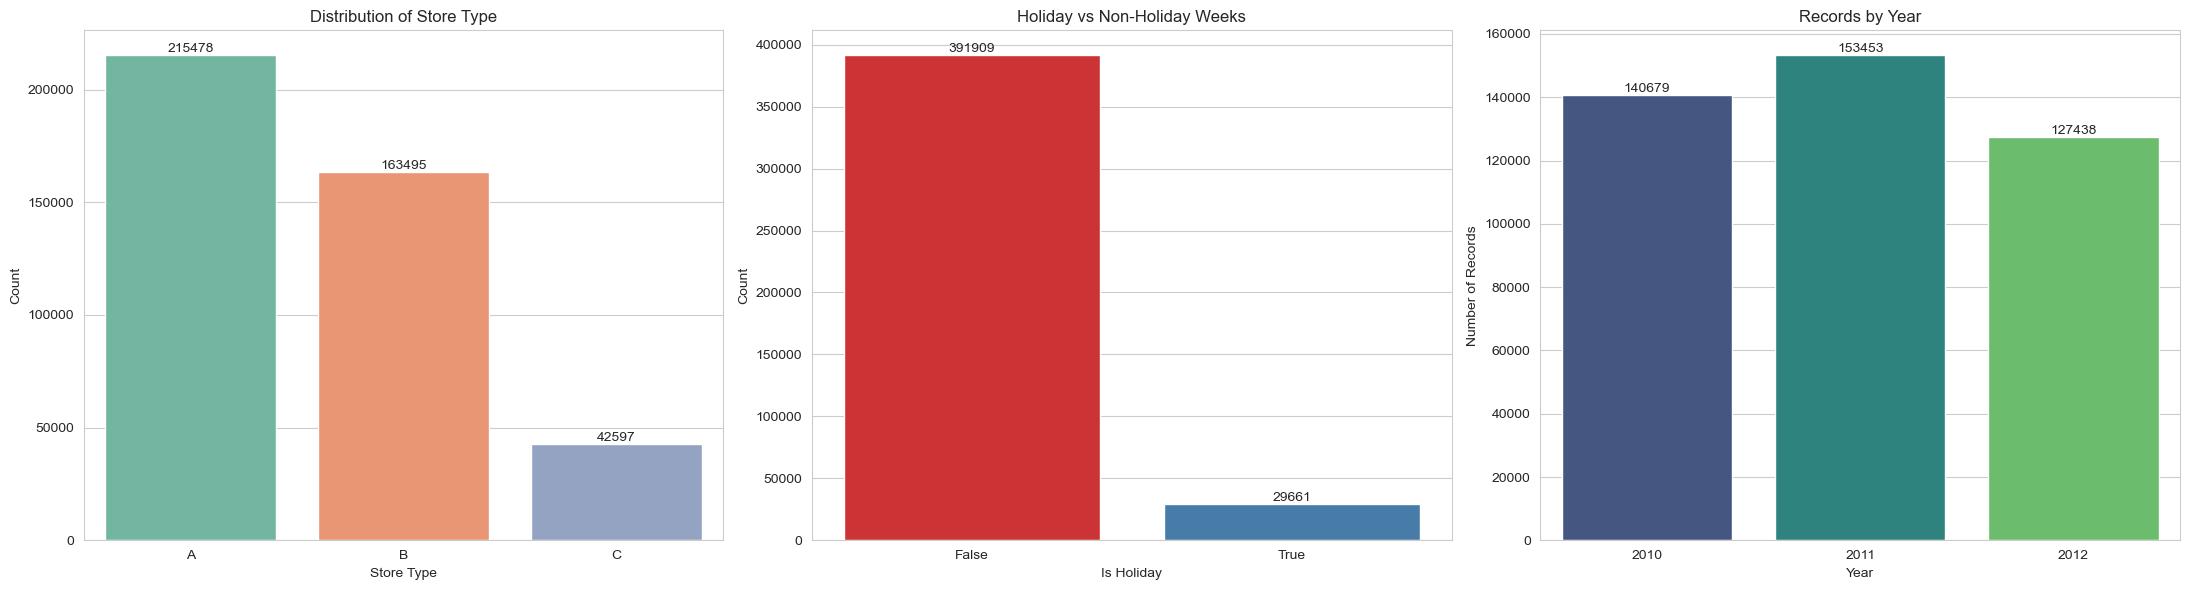

In [28]:
# Convert Date to datetime (if not already converted)
df['Date'] = pd.to_datetime(df['Date'])

# Create Figure
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# ===============================
# Plot 1 : Store Type
# ===============================

sns.countplot(
    data=df,
    x='Type',
    palette='Set2',
    ax=axes[0]
)

axes[0].set_title("Distribution of Store Type")
axes[0].set_xlabel("Store Type")
axes[0].set_ylabel("Count")

for container in axes[0].containers:
    axes[0].bar_label(container)


# ===============================
# Plot 2 : Holiday Distribution
# ===============================

sns.countplot(
    data=df,
    x='IsHoliday',
    palette='Set1',
    ax=axes[1]
)

axes[1].set_title("Holiday vs Non-Holiday Weeks")
axes[1].set_xlabel("Is Holiday")
axes[1].set_ylabel("Count")

for container in axes[1].containers:
    axes[1].bar_label(container)


# ===============================
# Plot 3 : Number of Records per Year
# ===============================

year_counts = df['Date'].dt.year.value_counts().sort_index()

sns.barplot(
    x=year_counts.index,
    y=year_counts.values,
    palette='viridis',
    ax=axes[2]
)

axes[2].set_title("Records by Year")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Number of Records")

for container in axes[2].containers:
    axes[2].bar_label(container)

plt.tight_layout()

plt.show()

In [29]:
print("="*60)
print("Store Type Distribution (%)")
print("="*60)

display(
    df['Type']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("="*60)
print("Holiday Distribution (%)")
print("="*60)

display(
    df['IsHoliday']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("="*60)
print("Records by Year")
print("="*60)

display(
    df['Date']
    .dt.year
    .value_counts()
    .sort_index()
)

Store Type Distribution (%)


Type
A    51.11
B    38.78
C    10.10
Name: proportion, dtype: float64

Holiday Distribution (%)


IsHoliday
False    92.96
True      7.04
Name: proportion, dtype: float64

Records by Year


Date
2010    140679
2011    153453
2012    127438
Name: count, dtype: int64

# Combined Observation of Categorical Features

The categorical variables **Type**, **IsHoliday**, and **Date (Year)** were analyzed to understand the composition of the dataset before investigating their relationship with weekly sales.

### Key Findings

### 1. Store Type

- The dataset contains three categories of Walmart stores: **Type A, Type B, and Type C**.
- **Type A** stores constitute the largest proportion of the dataset (**51.11%**), followed by **Type B (38.78%)**, while **Type C** stores account for only **10.10%** of the observations.
- This indicates that the dataset is moderately imbalanced with respect to store type, with Type A stores being more frequently represented.
- Since **Type** is a categorical feature, it will require categorical encoding before model training.

### 2. Holiday Distribution

- Approximately **92.96%** of the observations correspond to **non-holiday weeks**, whereas only **7.04%** represent **holiday weeks**.
- This indicates that holiday periods are relatively rare within the dataset.
- Although holiday observations are limited, they are expected to have a significant impact on weekly sales due to increased customer demand during festive seasons.
- Therefore, the **IsHoliday** feature is likely to be an important predictor despite its class imbalance.

### 3. Temporal Coverage

- The dataset spans **three years (2010–2012)**.
- The observations are reasonably distributed across all three years:
  - **2010:** 140,679 records
  - **2011:** 153,453 records
  - **2012:** 127,438 records
- The slight variation in yearly observations is expected because the dataset covers only a portion of **2012**, whereas **2010** and **2011** contain more complete weekly records.
- The availability of multiple years of historical data makes the dataset suitable for time series analysis and sales forecasting.

### Overall Conclusion

The categorical variables provide valuable business information regarding store categories, holiday periods, and temporal coverage. These features are expected to play an important role in explaining variations in weekly sales and will be explored further during the business analysis and time series analysis stages.
